## Imports

In [ ]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

## Data

In [2]:
x_train = 2 * torch.rand(200, 2) - 1
x_train

tensor([[-0.5025,  0.5571],
        [ 0.5541, -0.6300],
        [ 0.3173,  0.3468],
        [-0.0555, -0.9125],
        [-0.9127,  0.7372],
        [-0.3376, -0.4096],
        [ 0.8147, -0.7412],
        [-0.8423,  0.1900],
        [ 0.4762, -0.4298],
        [ 0.8374,  0.5174],
        [-0.9616,  0.2449],
        [ 0.9117,  0.9071],
        [ 0.7959,  0.0750],
        [ 0.0602, -0.1699],
        [ 0.2147, -0.0465],
        [ 0.9193, -0.4432],
        [-0.5445,  0.9078],
        [-0.2774, -0.5427],
        [ 0.3138, -0.9286],
        [ 0.5363, -0.5724],
        [ 0.3250,  0.7928],
        [ 0.8377, -0.9218],
        [ 0.2791,  0.5889],
        [-0.0771, -0.6097],
        [ 0.1500, -0.3888],
        [-0.5379,  0.7790],
        [-0.7602, -0.0936],
        [-0.1307,  0.8757],
        [-0.8127,  0.3781],
        [ 0.5929,  0.6176],
        [ 0.8048, -0.4751],
        [-0.1148, -0.2632],
        [ 0.4814, -0.5475],
        [-0.2584, -0.3613],
        [ 0.4168,  0.4613],
        [ 0.5264,  0

In [3]:
y_train = torch.rand(200)
y_train

tensor([0.1565, 0.0992, 0.4373, 0.7751, 0.0745, 0.6118, 0.4698, 0.3118, 0.5165,
        0.7117, 0.4990, 0.3546, 0.6239, 0.2902, 0.3543, 0.4306, 0.4419, 0.4753,
        0.8975, 0.1405, 0.9503, 0.0729, 0.2207, 0.1774, 0.0136, 0.4207, 0.0776,
        0.9951, 0.2490, 0.3108, 0.0135, 0.4169, 0.7040, 0.3200, 0.1545, 0.9034,
        0.1237, 0.9265, 0.6392, 0.8087, 0.8713, 0.5357, 0.2227, 0.2097, 0.5135,
        0.6002, 0.8514, 0.9700, 0.9306, 0.2475, 0.1420, 0.1481, 0.0671, 0.0617,
        0.9190, 0.3559, 0.4571, 0.0289, 0.4272, 0.0487, 0.5628, 0.4225, 0.6148,
        0.1357, 0.4656, 0.6434, 0.1508, 0.7158, 0.4072, 0.7293, 0.4424, 0.3335,
        0.5280, 0.5027, 0.2415, 0.5203, 0.1141, 0.0112, 0.5028, 0.9029, 0.9524,
        0.0300, 0.0868, 0.8218, 0.5382, 0.2793, 0.4303, 0.7158, 0.4317, 0.5462,
        0.0144, 0.6405, 0.1394, 0.8218, 0.4919, 0.5209, 0.6693, 0.9641, 0.5915,
        0.0068, 0.2874, 0.0250, 0.2265, 0.6635, 0.1027, 0.7559, 0.2627, 0.2835,
        0.1474, 0.7134, 0.8219, 0.4883, 

## Model

In [26]:
mf_distribution = [3, 2]

In [27]:
model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
)

In [28]:
prems = [
    torch.tensor([
        [ 0.8888,  1.4778, -0.9828],
        [ 0.6794,  1.9851,  1.3402],
        [ 0.3820,  1.2675,  0.1291]]), 
    torch.tensor([
        [ 0.2936,  1.4291, -0.4110],
        [ 0.7602,  1.9827,  0.5622]])
    ]

In [29]:
model.set_premises(prems)

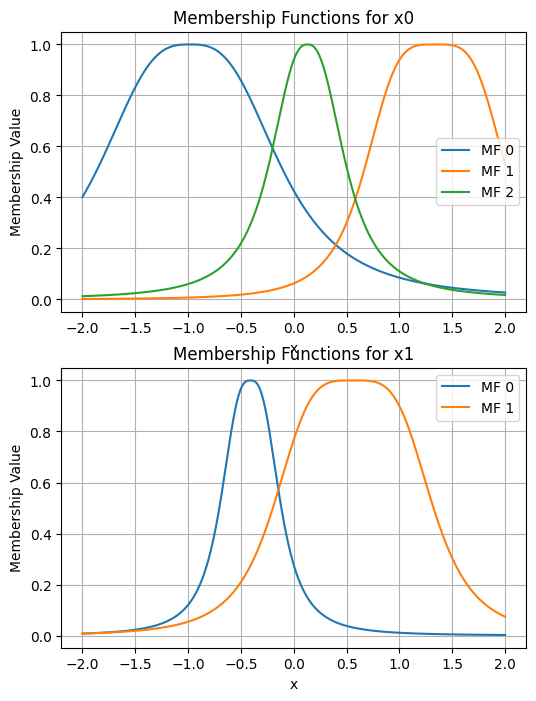

In [30]:
model.plot_premises(group_by_dim=True)

In [31]:
model.show_premises_structure()

      a (x0)  b (x0)  c (x0)  a (x1)  b (x1)  c (x1)
MF 0  0.8888  1.4778 -0.9828  0.2936  1.4291 -0.4110
MF 1  0.6794  1.9851  1.3402  0.7602  1.9827  0.5622
MF 2  0.3820  1.2675  0.1291     NaN     NaN     NaN


In [32]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.8888,1.4778,-0.9828,0.2936,1.4291,-0.4110
MF 1,0.6794,1.9851,1.3402,0.7602,1.9827,0.5622
MF 2,0.3820,1.2675,0.1291,NaN,NaN,NaN


In [33]:
model.get_premises()

[tensor([[ 0.8888,  1.4778, -0.9828],
         [ 0.6794,  1.9851,  1.3402],
         [ 0.3820,  1.2675,  0.1291]]),
 tensor([[ 0.2936,  1.4291, -0.4110],
         [ 0.7602,  1.9827,  0.5622]])]

## Binary output

In [392]:
x_train = 2 * torch.rand(200, 3) - 1

In [393]:
x_train[:10]

tensor([[ 0.3548,  0.5002,  0.9277],
        [ 0.9634, -0.8925,  0.3776],
        [-0.2472,  0.4155,  0.6998],
        [-0.8156, -0.8858, -0.8581],
        [-0.7510, -0.3350,  0.7338],
        [ 0.3599, -0.2020,  0.4650],
        [ 0.3146,  0.2245,  0.1090],
        [ 0.6138,  0.0325, -0.4810],
        [ 0.4188,  0.1325, -0.1735],
        [ 0.8298, -0.5847,  0.8245]])

In [394]:
mf_distribution

[3, 2, 3]

In [395]:
bin_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    output_type='binary', # Tipo de salida: clasificación binaria
)

In [396]:
bin_model.get_premises()

[tensor([[ 0.3861,  1.1781, -0.4510],
         [ 0.4011,  1.9416,  0.2481],
         [ 0.1975,  1.1856, -0.7613]]),
 tensor([[ 0.0240,  1.0577, -0.0656],
         [ 0.9577,  1.2237, -0.0230]]),
 tensor([[ 0.0562,  1.8837,  0.3307],
         [ 0.8264,  1.1510,  0.2530],
         [ 0.3645,  1.7966, -0.1036]])]

In [397]:
bin_model.get_consequents()

tensor([[[-0.4142,  0.5191, -0.9141,  0.6919],
         [-0.5222,  0.8171,  0.7787, -0.8418],
         [ 0.0828,  0.3983,  0.6923,  0.7140],
         [-0.3237, -0.6849, -0.4792,  0.4211],
         [ 0.7561, -0.5646, -0.7450, -0.5317],
         [-0.6904, -0.0300, -0.7538,  0.6912],
         [-0.1964,  0.3681,  0.8341, -0.3370],
         [ 0.9417,  0.4819, -0.5299,  0.1836],
         [-0.6022, -0.0412, -0.1553,  0.3791],
         [-0.7625,  0.2506, -0.2200, -0.5421],
         [-0.7212, -0.5095, -0.5840, -0.6210],
         [ 0.8169,  0.9520,  0.9819,  0.2435],
         [-0.3506, -0.2987, -0.0883, -0.6475],
         [ 0.9019,  0.1969,  0.5296,  0.6441],
         [ 0.5979,  0.4829,  0.8831, -0.6042],
         [ 0.7457,  0.6318,  0.4892,  0.3702],
         [ 0.5654, -0.6533,  0.6482,  0.9613],
         [-0.0411,  0.5795, -0.4764, -0.4232]]])

In [398]:
bin_model(x_train[:10])

tensor([0.1892, 0.3760, 0.2551, 0.5839, 0.5352, 0.3360, 0.4658, 0.4577, 0.4857,
        0.2792], grad_fn=<SigmoidBackward0>)

In [399]:
bin_model.predict(x_train[:10])

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0])

## Multiclass output

In [400]:
x_train = 2 * torch.rand(200, 3) - 1

In [401]:
mul_class_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    outputs=3, # 3 clases
    output_type='multiclass', # Tipo de salida: clasificación multiclase
)

In [402]:
mul_class_model(x_train[:10])

tensor([[ 0.1540,  0.0939,  0.2426],
        [-0.5684, -1.1335, -0.6306],
        [ 0.3715, -0.6234, -0.8917],
        [ 0.1403, -0.0185, -0.0422],
        [ 0.1061,  0.5803,  0.2461],
        [ 0.4154,  0.2090,  0.1386],
        [ 0.0684, -0.3463, -1.0440],
        [ 0.5045,  0.0111, -0.3665],
        [ 0.7300,  0.3041, -0.6382],
        [ 0.4923,  0.1150,  0.0087]], grad_fn=<SqueezeBackward1>)

In [403]:
mul_class_model(x_train[:10], return_probabilities=True)

tensor([[0.3296, 0.3103, 0.3601],
        [0.3987, 0.2266, 0.3747],
        [0.6051, 0.2238, 0.1711],
        [0.3723, 0.3176, 0.3101],
        [0.2662, 0.4277, 0.3062],
        [0.3888, 0.3163, 0.2948],
        [0.5027, 0.3320, 0.1653],
        [0.4928, 0.3009, 0.2063],
        [0.5242, 0.3424, 0.1334],
        [0.4344, 0.2978, 0.2678]], grad_fn=<SoftmaxBackward0>)

In [404]:
mul_class_model.predict(x_train[:10])

array([2, 0, 0, 0, 1, 0, 0, 0, 0, 0])